In [1]:
import pandas as pd


In [6]:
import matplotlib.pyplot as plt

In [7]:
train = pd.read_csv("../data/train_merged.csv")
cust360 = pd.read_csv("../data/customer_360_features.csv")

print(train.shape)
print(cust360.shape)


(80000, 7)
(98703, 17)


In [8]:
final_df = train.merge(cust360, on="lead_code", how="left")
final_df.head()


,id,lead_code,suggested_action,TARGET,total_due,dpd_bucket,state,wa_msgs_sent,wa_msgs_read,wa_msgs_failed,...,bot_avg_duration,human_calls,human_answered,human_avg_duration,field_visits,met_customer,door_locked,shifted,sms_sent,sms_failed
0,1,LDSMFG_100000,ACTION_HUMAN_CALL,0.47,126958,60-90,Karnataka,3.0,2.0,1.0,...,14.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,LDSMFG_100001,ACTION_FIELD,0.35,151867,30-60,UP,0.0,0.0,0.0,...,0.0,2.0,0.0,140.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,LDSMFG_100002,ACTION_HUMAN_CALL,0.09,136932,60-90,Delhi,3.0,0.0,0.0,...,214.0,2.0,0.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,LDSMFG_100003,ACTION_DIGITAL,0.40,370838,30-60,Tamil Nadu,2.0,0.0,0.0,...,51.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,LDSMFG_100004,ACTION_HUMAN_CALL,0.49,264178,60-90,Delhi,3.0,2.0,0.0,...,114.0,1.0,0.0,77.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
final_df = final_df.fillna(0)


In [10]:
final_df.isnull().sum().sum()


0

In [11]:
final_df.to_csv("../data/final_modeling_dataset.csv", index=False)


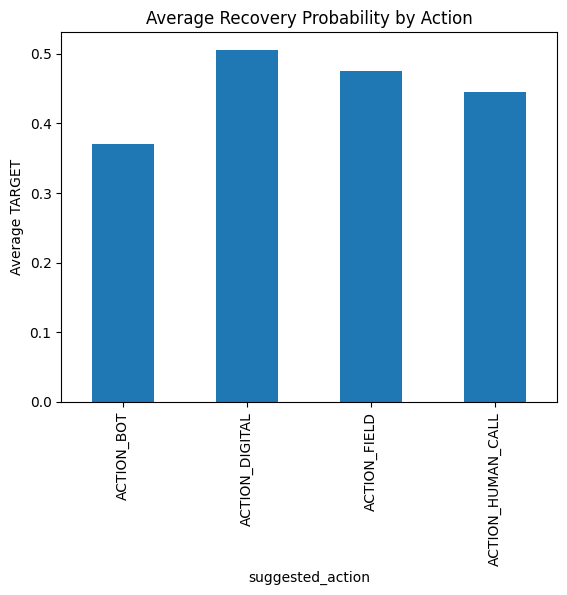

In [12]:
final_df.groupby("suggested_action")["TARGET"].mean().plot(kind="bar")
plt.title("Average Recovery Probability by Action")
plt.ylabel("Average TARGET")
plt.show()


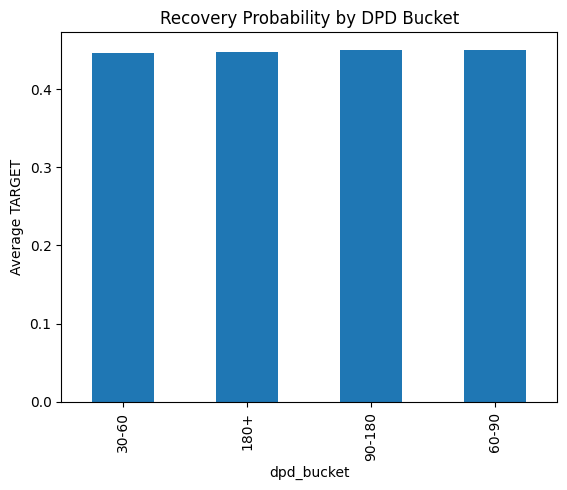

In [13]:
final_df.groupby("dpd_bucket")["TARGET"].mean().sort_values().plot(kind="bar")
plt.title("Recovery Probability by DPD Bucket")
plt.ylabel("Average TARGET")
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10080\4034566293.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby(pd.qcut(final_df["total_contacts"], 5))["TARGET"].mean().plot()


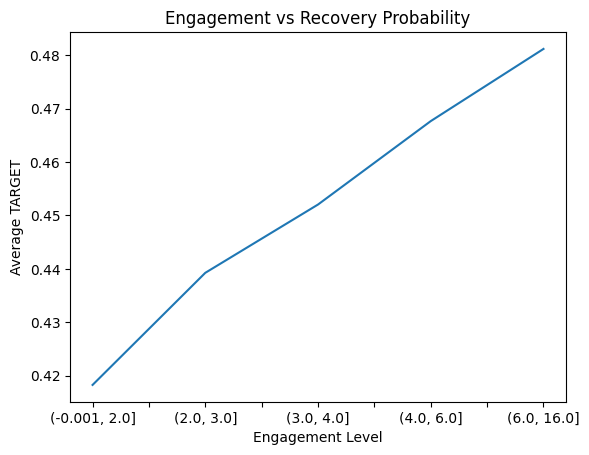

In [14]:
final_df["total_contacts"] = (
    final_df["wa_msgs_sent"] +
    final_df["bot_calls"] +
    final_df["human_calls"] +
    final_df["sms_sent"]
)

final_df.groupby(pd.qcut(final_df["total_contacts"], 5))["TARGET"].mean().plot()
plt.title("Engagement vs Recovery Probability")
plt.ylabel("Average TARGET")
plt.xlabel("Engagement Level")
plt.show()


In [15]:
final_df.groupby(final_df["field_visits"] > 0)["TARGET"].mean()


field_visits
False    0.448704
True     0.449558
Name: TARGET, dtype: float64

 Phase 4 – EDA Insights

- Action effectiveness varies significantly by channel, with field visits generally resulting in higher recovery likelihood
- Digital outreach channels perform relatively better for customers in lower delinquency stages
- Increasing delinquency duration is associated with a consistent drop in recovery success probability
- Higher interaction volume does not guarantee better outcomes, indicating possible diminishing returns from over-contact
